In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as io
import argparse
import matplotlib.pyplot as plt
import os
import sys
import gc
import wandb

from mmengine.optim import build_optim_wrapper

sys.path.append("/home/ids/edabier/HSU/HyperSIGMA/HyperspectralUnmixing")
from mmcv__custom import layer_decay_optimizer_constructor_vit

from src.utils import utils
from src.utils import plots
from src.models import foundation_models as rsfm
from src.models import models

import logging

def instantiate_model(Y, wavelengths, H):

    n_features = 1
    use_cls = False
    extend_cls = False

    if H < 224:
        Y_dofa = F.interpolate(Y, size=(224,224))
        H_dofa = 224
    else:
        Y_dofa = Y.clone()
        H_dofa = 224
    Y_dofa = Y_dofa[:,:,:H_dofa, :H_dofa]
    fm, _, _ = rsfm.create_fm("DOFA", Y_dofa, n_features=n_features, use_cls=use_cls, extend_cls=extend_cls)
    features_dofa = rsfm.get_dofa_features(fm, Y_dofa, wavelengths)
    D_dofa = int(features_dofa.shape[0]/n_features)
    alpha = int(features_dofa.shape[1]**0.5)

    return fm, D_dofa, alpha, H_dofa

def transform_Y(Y):
    batch, B, H, _ = Y.shape

    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
        new_H = 224
    else:
        new_H = 224
    Y = Y[:,:,:224, :224]
    return Y, new_H

def run_one_xp(i_dataset, i_train, n_train, i_xp, dataset, mse_tensor, sad_tensor, Y_init, wavelengths, B, c, H, dev):

    fm, D_dofa, alpha, new_H = instantiate_model(Y_init, wavelengths, H)
    sads, mses = [], []
    E_hats, A_hats = torch.zeros(n_train, B, c), torch.zeros(n_train, c, new_H, new_H)

    for i in range(n_train): 
        print(f"training {i}/{n_train}")

        model = rsfm.Unmixing_from_features(D=D_dofa, alpha=alpha, B=B, c=c, use_cls=False)
        # model = torch.compile(model)
        model.apply(model.weights_init)
        Y, new_H = transform_Y(Y_init)
        model = models.init_decoder_weights(model, Y/Y.max(), c, is_unmixer=True, use_sivm=True)

        loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)
        epochs, lr = 200, 0.002

        optim_wrapper = dict(
            optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
            constructor='LayerDecayOptimizerConstructor_ViT',
            paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
        optimizer = build_optim_wrapper(model, optim_wrapper)

        for epoch in range(epochs):
            
            for Y, E, A in loader:

                optimizer.zero_grad()
                
                Y = utils.oneD_to_2d(Y).to(dev)
                A = utils.oneD_to_2d(A).to(dev)
                E = E.to(dev)

                Y, A, features = rsfm.extract_f(fm, Y, new_H, wavelengths, A, use_cls=False)
                E_hat, A_hat, Y_hat = model(features)
                
                Yn = utils.sum_to_one(Y)
                W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.6, 0.09, 3e-5, 0, 0
                loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)

                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
                optimizer.step()
                
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)
                    
        model.eval()
        
        with torch.no_grad():
            _, A_init, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A, False)
            E_hat1, A_hat1, Y_hat1 = model(features)

        E_hats[i] = E_hat1
        A_hats[i] = A_hat1.squeeze(0)

        del E_hat1, A_hat1, Y_hat1, E_hat, A_hat, Y_hat, optimizer
        gc.collect()
        torch.cuda.empty_cache()
    
    sads_tensor = torch.tensor(sads)
    mses_tensor = torch.tensor(mses)
    mses_tensor = mses_tensor[~mses_tensor.isnan()]

    E_hat_m = torch.mean(E_hats, dim=0)
    A_hat_m = torch.mean(A_hats, dim=0)

    assert not E_hat_m.isnan().any(), "E_hat_m has nan values"

    sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
    print(f"Average SAD = {format(sad, '.3f')}, MSE = {format(mse, '.3f')}")

    mse_tensor[i_dataset, i_train, i_xp] = mse
    sad_tensor[i_dataset, i_train, i_xp] = sad

    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    gc.collect()

    return mse_tensor, sad_tensor

def main(dev):
    n_xp = 10
    step = 5

    datasets = ["samson", "apex", "jasper", "urban"] #["samson"]

    # shape (n_datasets, step, n_xp)
    mse_tensor = torch.zeros(len(datasets), 1, n_xp)
    sad_tensor = torch.zeros(len(datasets), 1, n_xp)

    for i_dataset, dataset in enumerate(datasets):

        print(f"####### {dataset} #######")
        
        data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
        Y_flat = torch.tensor(data["Y"], dtype=torch.float32).unsqueeze(0)
        E = torch.tensor(data["E"])
        B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

        Y = utils.oneD_to_2d(Y_flat)
        H = Y.shape[-1]

        with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
            lines = file.readlines()
            wavelengths = [float(line.strip()) for line in lines if line.strip()]

        mean_metrics = torch.zeros(1)
        std_metrics = torch.zeros(1)

        print(f"Training DOFA 1 time")

        for i_xp in range(n_xp):

            print(f"------ Running {i_xp+1}th experiment ------")
            mse_tensor, sad_tensor = run_one_xp(i_dataset, 0, 10, i_xp, dataset, mse_tensor, sad_tensor, Y, wavelengths, B, c, H, dev)
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
        
        metrics_i = (mse_tensor[i_dataset, 0] + sad_tensor[i_dataset, 0])/2
        mean_metrics[0] = torch.mean(metrics_i, dim=0)
        std_metrics[0] = torch.std(metrics_i, dim=0)
        print(f"NMSE: {mse_tensor[i_dataset].mean(dim=1)} ± {mse_tensor[i_dataset].std(dim=1)}")
        print(f"SAD: {sad_tensor[i_dataset].mean(dim=1)} ± {sad_tensor[i_dataset].std(dim=1)}")
        print(mean_metrics, std_metrics)

        # torch.save(mean_metrics, f"/home/ids/edabier/HSU/SS-HSU_benchmark/dofa_n_trains/{dataset}_DOFA_1_mean.pt")
        # torch.save(std_metrics, f"/home/ids/edabier/HSU/SS-HSU_benchmark/dofa_n_trains/{dataset}_DOFA_1_std.pt")
    return mse_tensor, sad_tensor

logging.getLogger().setLevel(logging.WARNING) 

if not torch.cuda.is_available():
    print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
    print("GPUs seen by torch:", torch.cuda.device_count())
    sys.exit("FATAL: CUDA not available — aborting")
else:
    dev = "cuda:0"
    torch.set_default_device(dev)

mse_tensor, sad_tensor = main(dev)

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

####### samson #######
Training DOFA 1 time
------ Running 1th experiment ------
training 0/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
training 8/10
{'num_layers': 12, 'layer_decay_r

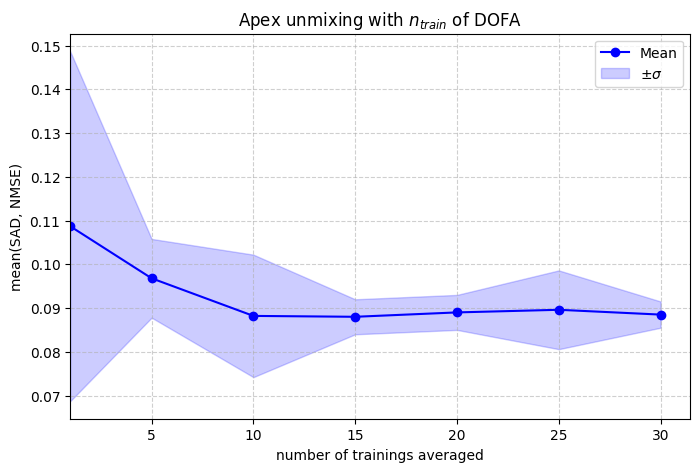

In [29]:
import numpy as np

samson_mean = np.array([0.0382, 0.0364, 0.039, 0.0347, 0.0353, 0.0348, 0.0353])
samson_std = np.array([0.004, 0.002, 0.006, 0.001, 0.001, 0.001, 0.002])

apex_mean = np.array([0.2122, 0.1296, 0.1302, 0.1168, 0.1155, 0.1113, 0.1144])
apex_std = np.array([0.207, 0.032, 0.034, 0.014, 0.015, 0.011, 0.012])

jasper_mean = np.array([0.1087, 0.0968, 0.0882, 0.088, 0.089, 0.0896, 0.0885])
jasper_std = np.array([0.04, 0.009, 0.014, 0.004, 0.004, 0.009, 0.003])

urban_mean = np.array([0.1883, 0.1621, 0.158, 0.1537, 0.158, 0.1578, 0.1581])
urban_std = np.array([0.025, 0.01, 0.01, 0.009, 0.005, 0.005, 0.005])

x = np.array([1, 5, 10, 15, 20, 25, 30])

plt.figure(figsize=(8, 5))

# Plot the mean as dots and lines
plt.plot(x, jasper_mean, 'o-', color='blue', label='Mean')

# Fill the area between mean ± std
plt.fill_between(
    x,
    jasper_mean - jasper_std,
    jasper_mean + jasper_std,
    color='blue',
    alpha=0.2,
    label=r'$\pm \sigma$'
)

plt.xlabel('number of trainings averaged')
plt.ylabel('mean(SAD, NMSE)')
plt.title(r'Apex unmixing with $n_{train}$ of DOFA')
plt.xlim(left=1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()